# 09 — 真实 IMDb 派生的 flat $\pm1$ vector QOS pilot

本章使用 IMDb 官方 train/test split 和 $D=4$ 的 signed feature hashing，
先在训练集上得到一个真实的 class-centroid 权重向量 $w$，再取

$$
s_j=\operatorname{sign}(w_j)\in\{+1,-1\}
$$

构造 flat sign state

$$
|s\rangle=\frac{1}{\sqrt D}\sum_{j=0}^{D-1}s_j|j\rangle.
$$

随后把原仓库 `qos_sampling.q_state_sketch_flat_unitary` 的显式采样公式
展开成只用两个地址量子位的 CP-based OpenQASM 2.0 线路。
真实 IMDb target 完全由上述固定预处理决定，没有为了得到某种 sign pattern
或纠缠性而调整 hash。另行加入的 $(+,+,+,-)$ 只作为明确标注的合成
entangled calibration control，不与真实 target 混合。

本章的准确定位是：

> **IMDb-derived flat-vector state-sketch primitive + 离线 Quafu-SQC 实验包。**

它不是 end-to-end IMDb streaming training，不是 LS-SVM，不是
general-vector QOS，也没有实现 QSVT。

## 1. 本章究竟验证什么

| 层次 | 本章是否实现 | 说明 |
|---|---:|---|
| IMDb 官方训练/测试数据 | 是 | 不把测试集用于训练 |
| $D=4$ signed `HashingVectorizer` | 是 | 无需学习词表 |
| 经典 class-centroid 权重 $w$ | 是 | 用作真实数据派生目标 |
| $\operatorname{sign}(w)$ 的 flat QOS | 是 | 如实保留真实 sign pattern 与负号数 $K$ |
| 合成 $(+,+,+,-)$ control | 是 | 独立标注的纠缠态 calibration，不是 IMDb target |
| 显式 IID component stream | 是 | 每条 stream 生成一条静态 QASM |
| Quafu-SQC 真机提交 | 否，默认关闭 | 只生成安全模板和 manifest |
| 非均匀振幅 general-vector QOS | 否 | 只给出下一层设计 |
| QSVT / LS-SVM / amplitude amplification | 否 | 不把未实现内容伪装成结果 |

三个容易混淆的数量：

- $D=4$：向量分量数，也是地址数；
- $M$：一条 QOS sketch 使用的经典 component samples 数；
- $R$：同一个 $M$ 下独立随机 stream/QASM 的条数；
- shots：同一条量子线路重复测量的次数，和 $M,R$ 都不同。

In [1]:
import hashlib
import json
import os
import platform
from getpass import getpass
from importlib.metadata import version as package_version
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/qos-imdb-mplconfig")

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import qiskit
import sklearn
from qiskit import QuantumCircuit, qasm2
from qiskit.circuit import Gate
from qiskit.quantum_info import Statevector
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import accuracy_score

SEED = 20260729
D = 4
N_ADDRESS = 2
M_VALUES = (4, 16, 32)
R_STREAMS = 20
S_SHOTS = 2048
QUAFUSQC_VERSION = package_version("quafusqc")

DEFAULT_IMDB_ROOT = Path("/private/tmp/qos-imdb-data/aclImdb")
DATA_ROOT = Path(
    os.environ.get("IMDB_DATA_ROOT", str(DEFAULT_IMDB_ROOT))
).expanduser()
RESULT_ROOT = Path("../results/imdb_vector_pilot")
QASM_DIR = RESULT_ROOT / "qasm"
RAW_RESULT_DIR = RESULT_ROOT / "raw_results"
FIGURE_DIR = Path("../assets/figures")
CIRCUIT_DIR = Path("../assets/circuits")

for directory in (
    RESULT_ROOT,
    QASM_DIR,
    RAW_RESULT_DIR,
    FIGURE_DIR,
    CIRCUIT_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "IMDb data not found. Set IMDB_DATA_ROOT to the aclImdb "
        "directory, or first run notebook 08's IMDb download/setup "
        "steps. Expected train/neg, train/pos, test/neg, test/pos."
    )

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("Qiskit:", qiskit.__version__)
print("quafusqc distribution:", QUAFUSQC_VERSION)
print("IMDb root:", DATA_ROOT)
print("Independent streams per M:", R_STREAMS)

Python: 3.13.7
scikit-learn: 1.9.0
Qiskit: 2.5.1
quafusqc distribution: 3.3.9
IMDb root: /private/tmp/qos-imdb-data/aclImdb
Independent streams per M: 20


## 2. 只用训练集得到 $D=4$ 的真实权重

`HashingVectorizer` 是无状态映射：这里固定 `n_features=4` 和
`alternate_sign=True`。训练集正负类均值分别为 $\mu_+$、$\mu_-$，
class-centroid 方向和截距为

$$
w=\mu_+-\mu_-,
\qquad
b=-\frac12\left(\|\mu_+\|_2^2-\|\mu_-\|_2^2\right).
$$

测试集只用于最后评估。flat-QOS 的目标是 $s=\operatorname{sign}(w)$，
它丢弃了 $|w_j|$，因此其经典分类准确率应与原始 centroid 分开报告。

In [2]:
def load_imdb_split(data_root, split):
    texts = []
    labels = []
    paths = []
    for label, class_name in ((-1, "neg"), (1, "pos")):
        class_paths = sorted((data_root / split / class_name).glob("*.txt"))
        for path in class_paths:
            texts.append(
                path.read_text(encoding="utf-8", errors="replace")
            )
            labels.append(label)
            paths.append(str(path.relative_to(data_root)))
    return texts, np.asarray(labels, dtype=np.int8), paths


train_texts, y_train, train_paths = load_imdb_split(
    DATA_ROOT, "train"
)
test_texts, y_test, test_paths = load_imdb_split(
    DATA_ROOT, "test"
)

vectorizer = HashingVectorizer(
    n_features=D,
    alternate_sign=True,
    norm="l2",
    lowercase=True,
    ngram_range=(1, 1),
)
X_train = vectorizer.transform(train_texts)
X_test = vectorizer.transform(test_texts)

mu_positive = np.asarray(
    X_train[y_train == 1].mean(axis=0)
).ravel()
mu_negative = np.asarray(
    X_train[y_train == -1].mean(axis=0)
).ravel()
centroid_weight = mu_positive - mu_negative
centroid_bias = -0.5 * (
    np.dot(mu_positive, mu_positive)
    - np.dot(mu_negative, mu_negative)
)

train_scores = np.asarray(X_train @ centroid_weight).ravel()
test_scores = np.asarray(X_test @ centroid_weight).ravel()
centroid_train_prediction = np.where(
    train_scores + centroid_bias >= 0, 1, -1
)
centroid_test_prediction = np.where(
    test_scores + centroid_bias >= 0, 1, -1
)
centroid_train_accuracy = accuracy_score(
    y_train, centroid_train_prediction
)
centroid_test_accuracy = accuracy_score(
    y_test, centroid_test_prediction
)

sign_vector = np.where(
    centroid_weight >= 0, 1, -1
).astype(np.int8)
flat_direction = sign_vector / np.sqrt(D)
flat_train_scores = np.asarray(
    X_train @ flat_direction
).ravel()
flat_test_scores = np.asarray(
    X_test @ flat_direction
).ravel()
flat_positive_mean = flat_train_scores[y_train == 1].mean()
flat_negative_mean = flat_train_scores[y_train == -1].mean()
flat_orientation = (
    1 if flat_positive_mean >= flat_negative_mean else -1
)
flat_threshold = 0.5 * (
    flat_positive_mean + flat_negative_mean
)
flat_train_prediction = np.where(
    flat_orientation * (flat_train_scores - flat_threshold) >= 0,
    1,
    -1,
)
flat_test_prediction = np.where(
    flat_orientation * (flat_test_scores - flat_threshold) >= 0,
    1,
    -1,
)
flat_train_accuracy = accuracy_score(
    y_train, flat_train_prediction
)
flat_test_accuracy = accuracy_score(
    y_test, flat_test_prediction
)

weight_table = pd.DataFrame(
    {
        "component_j": np.arange(D),
        "mu_positive": mu_positive,
        "mu_negative": mu_negative,
        "centroid_weight_wj": centroid_weight,
        "flat_sign_sj": sign_vector,
    }
)
display(weight_table)

print("Training reviews:", len(train_texts))
print("Test reviews:", len(test_texts))
print(
    "Centroid accuracy (train/test):",
    f"{centroid_train_accuracy:.4f}",
    f"{centroid_test_accuracy:.4f}",
)
print(
    "Sign-quantized diagnostic accuracy (train/test):",
    f"{flat_train_accuracy:.4f}",
    f"{flat_test_accuracy:.4f}",
)
print("IMDb-derived sign vector:", sign_vector.tolist())
print(
    "Negative components K:",
    int(np.sum(sign_vector == -1)),
)

model_payload = {
    "dataset": "Stanford ACL IMDb official train/test split",
    "data_root_used_for_execution": str(DATA_ROOT),
    "n_train": int(len(train_texts)),
    "n_test": int(len(test_texts)),
    "train_class_counts": {
        "-1": int(np.sum(y_train == -1)),
        "+1": int(np.sum(y_train == 1)),
    },
    "test_class_counts": {
        "-1": int(np.sum(y_test == -1)),
        "+1": int(np.sum(y_test == 1)),
    },
    "hashing_vectorizer": {
        "input": "content",
        "encoding": "utf-8",
        "decode_error": "strict",
        "strip_accents": None,
        "n_features": D,
        "analyzer": "word",
        "preprocessor": None,
        "tokenizer": None,
        "token_pattern": r"(?u)\b\w\w+\b",
        "stop_words": None,
        "binary": False,
        "alternate_sign": True,
        "dtype": "float64",
        "norm": "l2",
        "lowercase": True,
        "ngram_range": [1, 1],
    },
    "mu_positive": mu_positive.tolist(),
    "mu_negative": mu_negative.tolist(),
    "centroid_weight": centroid_weight.tolist(),
    "centroid_bias": float(centroid_bias),
    "centroid_train_accuracy": float(centroid_train_accuracy),
    "centroid_test_accuracy": float(centroid_test_accuracy),
    "flat_sign_vector": sign_vector.tolist(),
    "num_negative_components_K": int(
        np.sum(sign_vector == -1)
    ),
    "hash_seed_tuned_for_sign_pattern": False,
    "flat_threshold_from_train": float(flat_threshold),
    "flat_orientation_from_train": int(flat_orientation),
    "flat_train_accuracy": float(flat_train_accuracy),
    "flat_test_accuracy": float(flat_test_accuracy),
    "boundary": (
        "The sign-quantized vector is an IMDb-derived target. "
        "It is not an end-to-end QOS-trained classifier."
    ),
}
model_text = json.dumps(
    model_payload, indent=2, ensure_ascii=False
)
model_sha256 = hashlib.sha256(
    model_text.encode("utf-8")
).hexdigest()
model_payload["model_payload_sha256_before_hash_field"] = (
    model_sha256
)
model_path = RESULT_ROOT / "imdb_d4_model_summary.json"
model_path.write_text(
    json.dumps(model_payload, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

centroid_weight_norm = float(np.linalg.norm(centroid_weight))
if not centroid_weight_norm > 0:
    raise ValueError("The trained D=4 centroid vector has zero norm.")
target_payload = {
    "schema_version": 1,
    "dataset": "Stanford ACL IMDb official train/test split",
    "D": D,
    "component_order": list(range(D)),
    "raw_vector": centroid_weight.tolist(),
    "normalized_vector": (
        centroid_weight / centroid_weight_norm
    ).tolist(),
    "norm": centroid_weight_norm,
    "sign_pattern": sign_vector.tolist(),
    "num_negative_components_K": int(
        np.sum(sign_vector == -1)
    ),
    "hashing_config": model_payload["hashing_vectorizer"],
    "hash_seed_tuned_for_sign_pattern": False,
    "scikit_learn_version": sklearn.__version__,
    "training_definition": {
        "estimator": "class-centroid direction",
        "formula": "mean(train positive) - mean(train negative)",
        "fit_split": "official train only",
        "evaluation_split": "official test only",
        "labels": {"negative": -1, "positive": 1},
    },
    "source_model_summary": model_path.name,
    "model_payload_sha256": model_sha256,
}
target_path = RESULT_ROOT / "imdb_d4_target.json"
target_path.write_text(
    json.dumps(target_payload, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
weight_table.to_csv(
    RESULT_ROOT / "imdb_d4_weights.csv", index=False
)
print("Saved model summary:", model_path)
print("Saved reusable target:", target_path)

,component_j,mu_positive,mu_negative,centroid_weight_wj,flat_sign_sj
0,0,0.419190,0.339049,0.080141,1
1,1,0.185759,0.265565,-0.079806,-1
2,2,0.022826,0.104898,-0.082072,-1
3,3,-0.113925,-0.096863,-0.017062,-1


Training reviews: 25000
Test reviews: 25000
Centroid accuracy (train/test): 0.5660 0.5535
Sign-quantized diagnostic accuracy (train/test): 0.5616 0.5505
IMDb-derived sign vector: [1, -1, -1, -1]
Negative components K: 3
Saved model summary: ../results/imdb_vector_pilot/imdb_d4_model_summary.json
Saved reusable target: ../results/imdb_vector_pilot/imdb_d4_target.json


## 3. Flat $\pm1$ QOS 与 Boolean phase QOS 是同一个门级 primitive

对每个分量定义

$$
g_j=\frac{1-s_j}{2}\in\{0,1\}.
$$

从 $j\in\{0,\ldots,D-1\}$ 均匀抽取 $M$ 个 component samples。
令 $C_j$ 为地址 $j$ 出现的次数，每个负号样本使用

$$
\theta=\frac{\pi D}{M}
$$

并作用

$$
\exp\left(i\theta |j\rangle\langle j|\right).
$$

因此 sampled sketch 是

$$
\widetilde U_s
=
\prod_{t=1}^{M}
\exp\left(
i\theta g_{j_t}|j_t\rangle\langle j_t|
\right).
$$

把它作用到 $|+\rangle^{\otimes2}$ 后，再接精确 sign oracle 的逆，
echo 成功率为

$$
F_{\rm echo}
=
\left|
\frac1D\sum_j
\exp\left\{
i\left[\theta C_j-\pi\right]g_j
\right\}
\right|^2.
$$

这里 $F_{\rm echo}=P(00)$ 是固定输入上的 state fidelity，不是 channel
或 process fidelity。

### 为什么这次不用工作 ancilla

$D=4$ 时，先用 X mask 把目标地址映射到 $|11\rangle$，再施加
$CP(\phi)$ 即可。为提高 OpenQASM 2.0 可移植性，本章把它展开成

```text
U1(phi/2) on q0
→ CX(q0,q1)
→ U1(-phi/2) on q1
→ CX(q0,q1)
→ U1(phi/2) on q1
```

它只用两个地址 qubits；每个有效 update 使用 2 个 CX。

In [3]:
def text_sha256(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def stream_sha256(stream):
    return hashlib.sha256(
        np.asarray(stream, dtype=np.int64).tobytes()
    ).hexdigest()


def append_cp_projector_qasm(
    lines,
    address,
    angle,
    preserve_sample_boundary=True,
):
    if not 0 <= int(address) < D:
        raise ValueError("Address must be in {0,1,2,3}.")

    zero_bits = [
        bit
        for bit in range(N_ADDRESS)
        if ((int(address) >> bit) & 1) == 0
    ]
    for bit in zero_bits:
        lines.append(f"x q[{bit}];")

    half_angle = float(angle) / 2
    lines.append(f"u1({half_angle:.16g}) q[0];")
    lines.append("cx q[0],q[1];")
    lines.append(f"u1({-half_angle:.16g}) q[1];")
    lines.append("cx q[0],q[1];")
    lines.append(f"u1({half_angle:.16g}) q[1];")

    for bit in reversed(zero_bits):
        lines.append(f"x q[{bit}];")
    if preserve_sample_boundary:
        lines.append("barrier q;")


def qasm_header():
    return [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        "qreg q[2];",
        "creg c[2];",
    ]


def append_initial_plus(lines):
    lines.extend(["h q[0];", "h q[1];", "barrier q;"])


def append_final_echo_measure(lines):
    lines.extend(
        [
            "barrier q;",
            "h q[0];",
            "h q[1];",
            "measure q[0] -> c[0];",
            "measure q[1] -> c[1];",
        ]
    )


def append_exact_sign_oracle(
    lines,
    signs,
    angle,
    preserve_boundaries=True,
):
    for address, sign in enumerate(signs):
        if int(sign) == -1:
            append_cp_projector_qasm(
                lines,
                address,
                angle,
                preserve_sample_boundary=preserve_boundaries,
            )


def build_h_only_qasm():
    lines = qasm_header()
    append_initial_plus(lines)
    append_final_echo_measure(lines)
    return "\n".join(lines) + "\n"


def build_exact_pair_qasm(signs):
    lines = qasm_header()
    append_initial_plus(lines)
    append_exact_sign_oracle(lines, signs, np.pi)
    lines.append("barrier q;")
    append_exact_sign_oracle(lines, signs, -np.pi)
    append_final_echo_measure(lines)
    return "\n".join(lines) + "\n"


def build_sampled_flat_echo_qasm(
    signs,
    stream,
    preserve_sample_boundaries=True,
):
    signs = np.asarray(signs, dtype=np.int8)
    stream = np.asarray(stream, dtype=np.int64)
    if len(signs) != D:
        raise ValueError("This pilot is fixed to D=4.")
    if len(stream) == 0:
        raise ValueError("The sampled stream must not be empty.")
    if np.any((stream < 0) | (stream >= D)):
        raise ValueError("Stream contains an invalid address.")

    theta = np.pi * D / len(stream)
    lines = qasm_header()
    append_initial_plus(lines)
    for address in stream:
        if signs[int(address)] == -1:
            append_cp_projector_qasm(
                lines,
                int(address),
                theta,
                preserve_sample_boundary=preserve_sample_boundaries,
            )
        elif preserve_sample_boundaries:
            lines.append("barrier q;")

    lines.append("barrier q;")
    append_exact_sign_oracle(
        lines,
        signs,
        -np.pi,
        preserve_boundaries=preserve_sample_boundaries,
    )
    append_final_echo_measure(lines)
    return "\n".join(lines) + "\n"


def direct_echo_state(signs, stream):
    signs = np.asarray(signs, dtype=np.int8)
    stream = np.asarray(stream, dtype=np.int64)
    indicator = (1 - signs) // 2
    theta = np.pi * D / len(stream)
    counts = np.bincount(stream, minlength=D)
    residual = np.exp(
        1j * (theta * counts - np.pi) * indicator
    )

    output = np.empty(D, dtype=np.complex128)
    for y in range(D):
        walsh_signs = np.asarray(
            [
                -1 if (x & y).bit_count() % 2 else 1
                for x in range(D)
            ]
        )
        output[y] = np.dot(walsh_signs, residual) / D
    return output


def direct_echo_fidelity(signs, stream):
    return float(abs(direct_echo_state(signs, stream)[0]) ** 2)


def expected_physical_echo_fidelity(
    n_states,
    num_negative,
    m_data,
):
    theta = np.pi * n_states / m_data
    a = (
        1 - 1 / n_states
        + np.exp(1j * theta) / n_states
    ) ** m_data
    b = (
        1
        + 2 * (np.cos(theta) - 1) / n_states
    ) ** m_data
    num_positive = n_states - num_negative
    return float(
        (
            num_positive**2
            + num_negative
            + num_negative * (num_negative - 1) * b
            - 2
            * num_negative
            * num_positive
            * np.real(a)
        )
        / n_states**2
    )


def qasm_state_metrics(qasm_text):
    circuit = qasm2.loads(qasm_text)
    bare = circuit.remove_final_measurements(inplace=False)
    state = np.asarray(
        Statevector.from_instruction(bare).data
    )
    return circuit, state, float(abs(state[0]) ** 2)


def aligned_state_error(direct_state, qasm_state):
    overlap = np.vdot(direct_state, qasm_state)
    if abs(overlap) < 1e-14:
        return np.inf
    phase = overlap / abs(overlap)
    return float(
        np.linalg.norm(qasm_state / phase - direct_state)
    )


print("CP-based QASM helpers ready.")

CP-based QASM helpers ready.


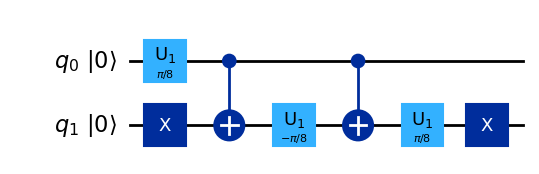

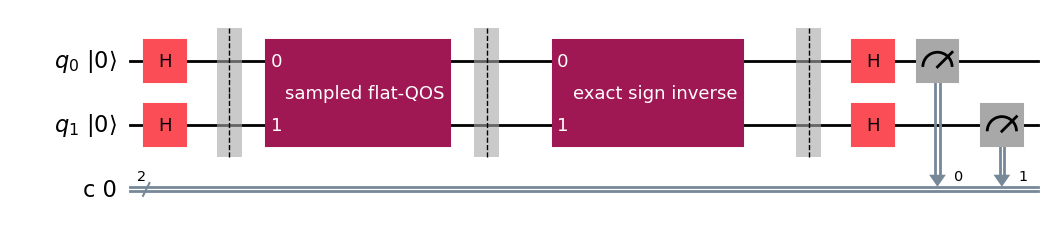

Saved: ../assets/circuits/imdb-flat-qos-cp-update.png
Saved: ../assets/circuits/imdb-flat-qos-echo-overview.png


In [4]:
# 单个 projector update：用地址 1 展示 X mask 和 CP 分解。
update_lines = qasm_header()
append_cp_projector_qasm(
    update_lines,
    address=1,
    angle=np.pi / 4,
    preserve_sample_boundary=False,
)
update_circuit = qasm2.loads("\n".join(update_lines) + "\n")
update_figure = update_circuit.draw(
    output="mpl",
    fold=-1,
    idle_wires=False,
    initial_state=True,
)
update_path = CIRCUIT_DIR / "imdb-flat-qos-cp-update.png"
update_figure.savefig(update_path, dpi=180, bbox_inches="tight")
display(update_figure)

# 高层概览：这里只用于解释结构，不作为提交线路。
overview = QuantumCircuit(2, 2)
overview.h([0, 1])
overview.barrier()
overview.append(Gate("sampled flat-QOS", 2, []), [0, 1])
overview.barrier()
overview.append(Gate("exact sign inverse", 2, []), [0, 1])
overview.barrier()
overview.h([0, 1])
overview.measure([0, 1], [0, 1])
overview_figure = overview.draw(
    output="mpl",
    fold=-1,
    idle_wires=False,
    initial_state=True,
)
overview_path = CIRCUIT_DIR / "imdb-flat-qos-echo-overview.png"
overview_figure.savefig(
    overview_path, dpi=180, bbox_inches="tight"
)
display(overview_figure)

print("Saved:", update_path)
print("Saved:", overview_path)

## 4. 功能 controls 与 IID campaign

本实验包包含：

| control | 理想 $F_{\rm echo}$ | 能检查什么 |
|---|---:|---|
| H-only | 1 | 最浅的制备/反制备/读出基线 |
| exact-pair | 1 | 精确 sign oracle 与逆是否抵消 |
| balanced $M=16$ | 1 | 每个地址出现 4 次，sampled sketch 严格等于目标 |
| fixed phase-count probe | 由计数公式给出 | 非均匀计数是否产生正确部分相位 |
| synthetic entangled $(+,+,+,-)$ | 1 | 独立的 $CZ|++\rangle$ calibration control |
| IID $M=4,16,32$ | 随 stream 改变 | 采样误差随 $M$ 的变化 |

balanced control 和 IID 线路都使用相同的静态 QASM 生成器；主线路保留
sample barrier。barrier 不是量子门，也不会把静态 QASM 变成在线 controller。

In [5]:
campaign_rng = np.random.default_rng(SEED + 900)
SYNTHETIC_ENTANGLED_SIGNS = np.asarray(
    [1, 1, 1, -1], dtype=np.int8
)
specs = []

specs.extend(
    [
        {
            "control_type": "h_only",
            "M_data": 0,
            "stream_mode": "none",
            "stream": np.asarray([], dtype=np.int64),
            "replicate": 0,
        },
        {
            "control_type": "exact_pair",
            "M_data": 0,
            "stream_mode": "none",
            "stream": np.asarray([], dtype=np.int64),
            "replicate": 0,
        },
    ]
)

balanced_stream = np.tile(np.arange(D), 4)
campaign_rng.shuffle(balanced_stream)
specs.append(
    {
        "control_type": "balanced_stream",
        "M_data": 16,
        "stream_mode": "balanced",
        "stream": balanced_stream,
        "replicate": 0,
    }
)

probe_stream = np.concatenate(
    [
        np.repeat(0, 4),
        np.repeat(1, 3),
        np.repeat(2, 4),
        np.repeat(3, 5),
    ]
).astype(np.int64)
campaign_rng.shuffle(probe_stream)
specs.append(
    {
        "control_type": "phase_count_probe",
        "M_data": 16,
        "stream_mode": "fixed_counts_4_3_4_5",
        "stream": probe_stream,
        "replicate": 0,
    }
)

synthetic_balanced_stream = np.tile(np.arange(D), 2)
synthetic_rng = np.random.default_rng(SEED + 901)
synthetic_rng.shuffle(synthetic_balanced_stream)
specs.append(
    {
        "control_type": "synthetic_entangled_balanced",
        "M_data": 8,
        "stream_mode": "balanced",
        "stream": synthetic_balanced_stream,
        "replicate": 0,
        "target_signs": SYNTHETIC_ENTANGLED_SIGNS,
        "target_source": (
            "fixed synthetic calibration target; not IMDb"
        ),
    }
)

for m_data in M_VALUES:
    for replicate in range(R_STREAMS):
        specs.append(
            {
                "control_type": "iid",
                "M_data": int(m_data),
                "stream_mode": "iid",
                "stream": campaign_rng.integers(
                    0,
                    D,
                    size=m_data,
                    dtype=np.int64,
                ),
                "replicate": replicate,
            }
        )

for stale_qasm in QASM_DIR.glob("imdb_flat_*.qasm"):
    stale_qasm.unlink()

manifest_entries = []
iid_rows = []
max_full_state_error = 0.0
representative_probe_qasm = None
synthetic_entangled_qasm = None

for experiment_index, spec in enumerate(specs, start=1):
    control_type = spec["control_type"]
    stream = np.asarray(spec["stream"], dtype=np.int64)
    target_signs = np.asarray(
        spec.get("target_signs", sign_vector),
        dtype=np.int8,
    )
    target_source = spec.get(
        "target_source",
        "IMDb D=4 signed-hash class-centroid sign vector",
    )

    if control_type == "h_only":
        qasm_text = build_h_only_qasm()
        ideal_fidelity = 1.0
        state_error = 0.0
    elif control_type == "exact_pair":
        qasm_text = build_exact_pair_qasm(target_signs)
        ideal_fidelity = 1.0
        state_error = 0.0
    else:
        qasm_text = build_sampled_flat_echo_qasm(
            target_signs,
            stream,
            preserve_sample_boundaries=True,
        )
        ideal_fidelity = direct_echo_fidelity(
            target_signs, stream
        )

    circuit, qasm_state, statevector_fidelity = (
        qasm_state_metrics(qasm_text)
    )
    if control_type not in {"h_only", "exact_pair"}:
        direct_state = direct_echo_state(target_signs, stream)
        state_error = aligned_state_error(
            direct_state, qasm_state
        )
        max_full_state_error = max(
            max_full_state_error, state_error
        )

    if abs(statevector_fidelity - ideal_fidelity) >= 1e-10:
        raise AssertionError(
            (
                control_type,
                ideal_fidelity,
                statevector_fidelity,
            )
        )

    experiment_id = (
        f"imdb_flat_{experiment_index:03d}_"
        f"{control_type}_M{spec['M_data']}_"
        f"r{spec['replicate']}"
    )
    qasm_path = QASM_DIR / f"{experiment_id}.qasm"
    qasm_path.write_text(qasm_text, encoding="utf-8")
    project_relative_qasm_path = (
        Path("results")
        / "imdb_vector_pilot"
        / "qasm"
        / qasm_path.name
    )

    operations = dict(circuit.count_ops())
    task_template = {
        "chip": "Baihua",
        "name": experiment_id,
        "circuit_file": str(project_relative_qasm_path),
        "shots": S_SHOTS,
        "compile": True,
        "options": {
            "compiler": "quarkcircuit",
            "correct": False,
            "open_dd": None,
            "target_qubits": [],
        },
    }
    manifest_entry = {
        "experiment_id": experiment_id,
        "control_type": control_type,
        "source": target_source,
        "D": D,
        "n_address": N_ADDRESS,
        "n_total_qubits": circuit.num_qubits,
        "algorithmic_ancillas": 0,
        "flat_sign_vector": target_signs.tolist(),
        "num_negative_components_K": int(
            np.sum(target_signs == -1)
        ),
        "model_sha256": (
            model_sha256
            if target_source.startswith("IMDb")
            else None
        ),
        "M_data": int(spec["M_data"]),
        "R_stream_index": int(spec["replicate"]),
        "S_shots": S_SHOTS,
        "stream_mode": spec["stream_mode"],
        "stream": stream.tolist(),
        "stream_sha256": stream_sha256(stream),
        "ideal_F_echo": float(ideal_fidelity),
        "statevector_F_echo": float(statevector_fidelity),
        "full_state_l2_error": float(state_error),
        "qasm_path": str(project_relative_qasm_path),
        "qasm_sha256": text_sha256(qasm_text),
        "logical_depth": circuit.depth(),
        "logical_h": int(operations.get("h", 0)),
        "logical_x": int(operations.get("x", 0)),
        "logical_u1": int(operations.get("u1", 0)),
        "logical_cx": int(operations.get("cx", 0)),
        "logical_barrier": int(operations.get("barrier", 0)),
        "recommended_functional_pilot": (
            control_type
            in {
                "h_only",
                "exact_pair",
                "balanced_stream",
                "phase_count_probe",
                "synthetic_entangled_balanced",
            }
        ),
        "task_template": task_template,
    }
    manifest_entries.append(manifest_entry)

    if control_type == "iid":
        iid_rows.append(
            {
                "experiment_id": experiment_id,
                "M_data": int(spec["M_data"]),
                "M_over_D": int(spec["M_data"]) / D,
                "R_stream_index": int(spec["replicate"]),
                "ideal_F_echo": float(ideal_fidelity),
                "logical_cx": int(operations.get("cx", 0)),
                "negative_sample_count": int(
                    np.sum(target_signs[stream] == -1)
                ),
                "stream_sha256": stream_sha256(stream),
                "qasm_sha256": text_sha256(qasm_text),
            }
        )

    if control_type == "phase_count_probe":
        representative_probe_qasm = qasm_text
    if control_type == "synthetic_entangled_balanced":
        synthetic_entangled_qasm = qasm_text

assert max_full_state_error < 1e-10
assert len(manifest_entries) == 5 + len(M_VALUES) * R_STREAMS
assert all(
    qasm2.loads(
        (Path("..") / entry["qasm_path"]).read_text(
            encoding="utf-8"
        )
    )
    is not None
    for entry in manifest_entries
)

manifest_path = RESULT_ROOT / "manifest.json"
manifest_path.write_text(
    json.dumps(manifest_entries, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
manifest_frame = pd.DataFrame(
    [
        {
            key: value
            for key, value in entry.items()
            if key not in {"stream", "task_template"}
        }
        for entry in manifest_entries
    ]
)
manifest_frame.to_csv(
    RESULT_ROOT / "manifest.csv", index=False
)

iid_streams = pd.DataFrame(iid_rows)
iid_streams.to_csv(
    RESULT_ROOT / "ideal_iid_streams.csv", index=False
)

summary_rows = []
num_negative = int(np.sum(sign_vector == -1))
for m_data, group in iid_streams.groupby("M_data"):
    mean_fidelity = group["ideal_F_echo"].mean()
    standard_error = (
        group["ideal_F_echo"].std(ddof=1)
        / np.sqrt(len(group))
    )
    summary_rows.append(
        {
            "M_data": int(m_data),
            "M_over_D": int(m_data) / D,
            "R_streams": len(group),
            "analytic_E_F_echo": (
                expected_physical_echo_fidelity(
                    D, num_negative, int(m_data)
                )
            ),
            "mean_MC_F_echo": mean_fidelity,
            "approx_normal_ci95_halfwidth": (
                1.96 * standard_error
            ),
            "mean_logical_cx": group[
                "logical_cx"
            ].mean(),
            "mean_negative_sample_count": group[
                "negative_sample_count"
            ].mean(),
        }
    )
ideal_summary = pd.DataFrame(summary_rows).sort_values(
    "M_data"
)
ideal_summary.to_csv(
    RESULT_ROOT / "ideal_summary.csv", index=False
)

control_summary = manifest_frame[
    manifest_frame["control_type"] != "iid"
][
    [
        "experiment_id",
        "control_type",
        "M_data",
        "ideal_F_echo",
        "logical_cx",
        "logical_depth",
    ]
]

display(control_summary)
display(ideal_summary)
print("Generated QASM files:", len(manifest_entries))
print("Maximum direct-vs-QASM full-state error:", max_full_state_error)
print("Manifest:", manifest_path)

,experiment_id,control_type,M_data,ideal_F_echo,logical_cx,logical_depth
0,imdb_flat_001_h_only_M0_r0,h_only,0,1.000000,0,3
1,imdb_flat_002_exact_pair_M0_r0,exact_pair,0,1.000000,12,37
2,imdb_flat_003_balanced_stream_M16_r0,balanced_stream,16,1.000000,30,88
3,imdb_flat_004_phase_count_probe_M16_r0,phase_count_probe,16,0.728553,30,87
4,imdb_flat_005_synthetic_entangled_balanced_M8_r0,synthetic_entangled_balanced,8,1.000000,6,18


,M_data,M_over_D,R_streams,analytic_E_F_echo,mean_MC_F_echo,approx_normal_ci95_halfwidth,mean_logical_cx,mean_negative_sample_count
0,4,1.0,20,0.226562,0.200000,0.098000,12.0,3.0
1,16,4.0,20,0.426437,0.456066,0.131346,31.0,12.5
2,32,8.0,20,0.594159,0.510156,0.121464,54.6,24.3


Generated QASM files: 65
Maximum direct-vs-QASM full-state error: 1.5667698370617513e-15
Manifest: ../results/imdb_vector_pilot/manifest.json


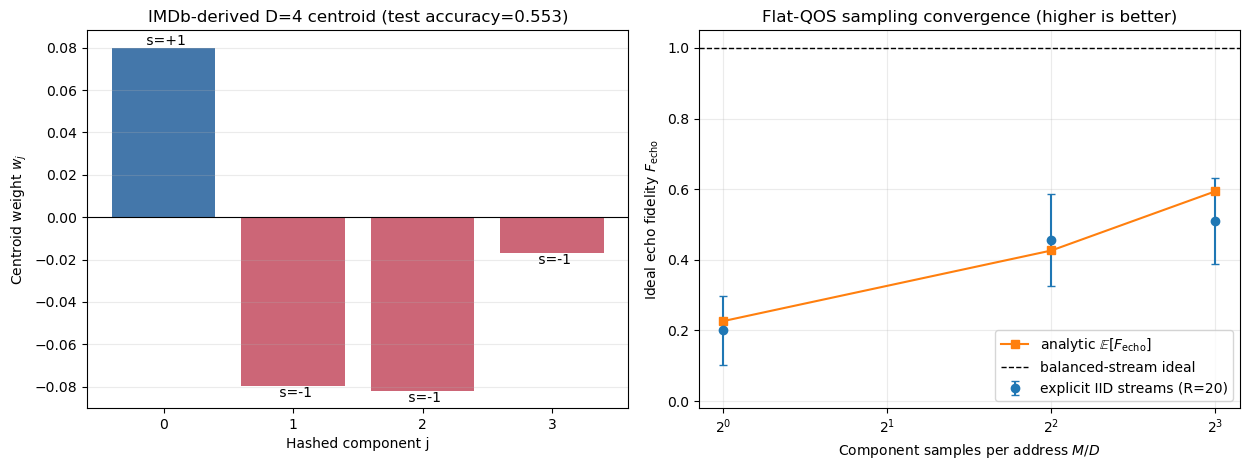

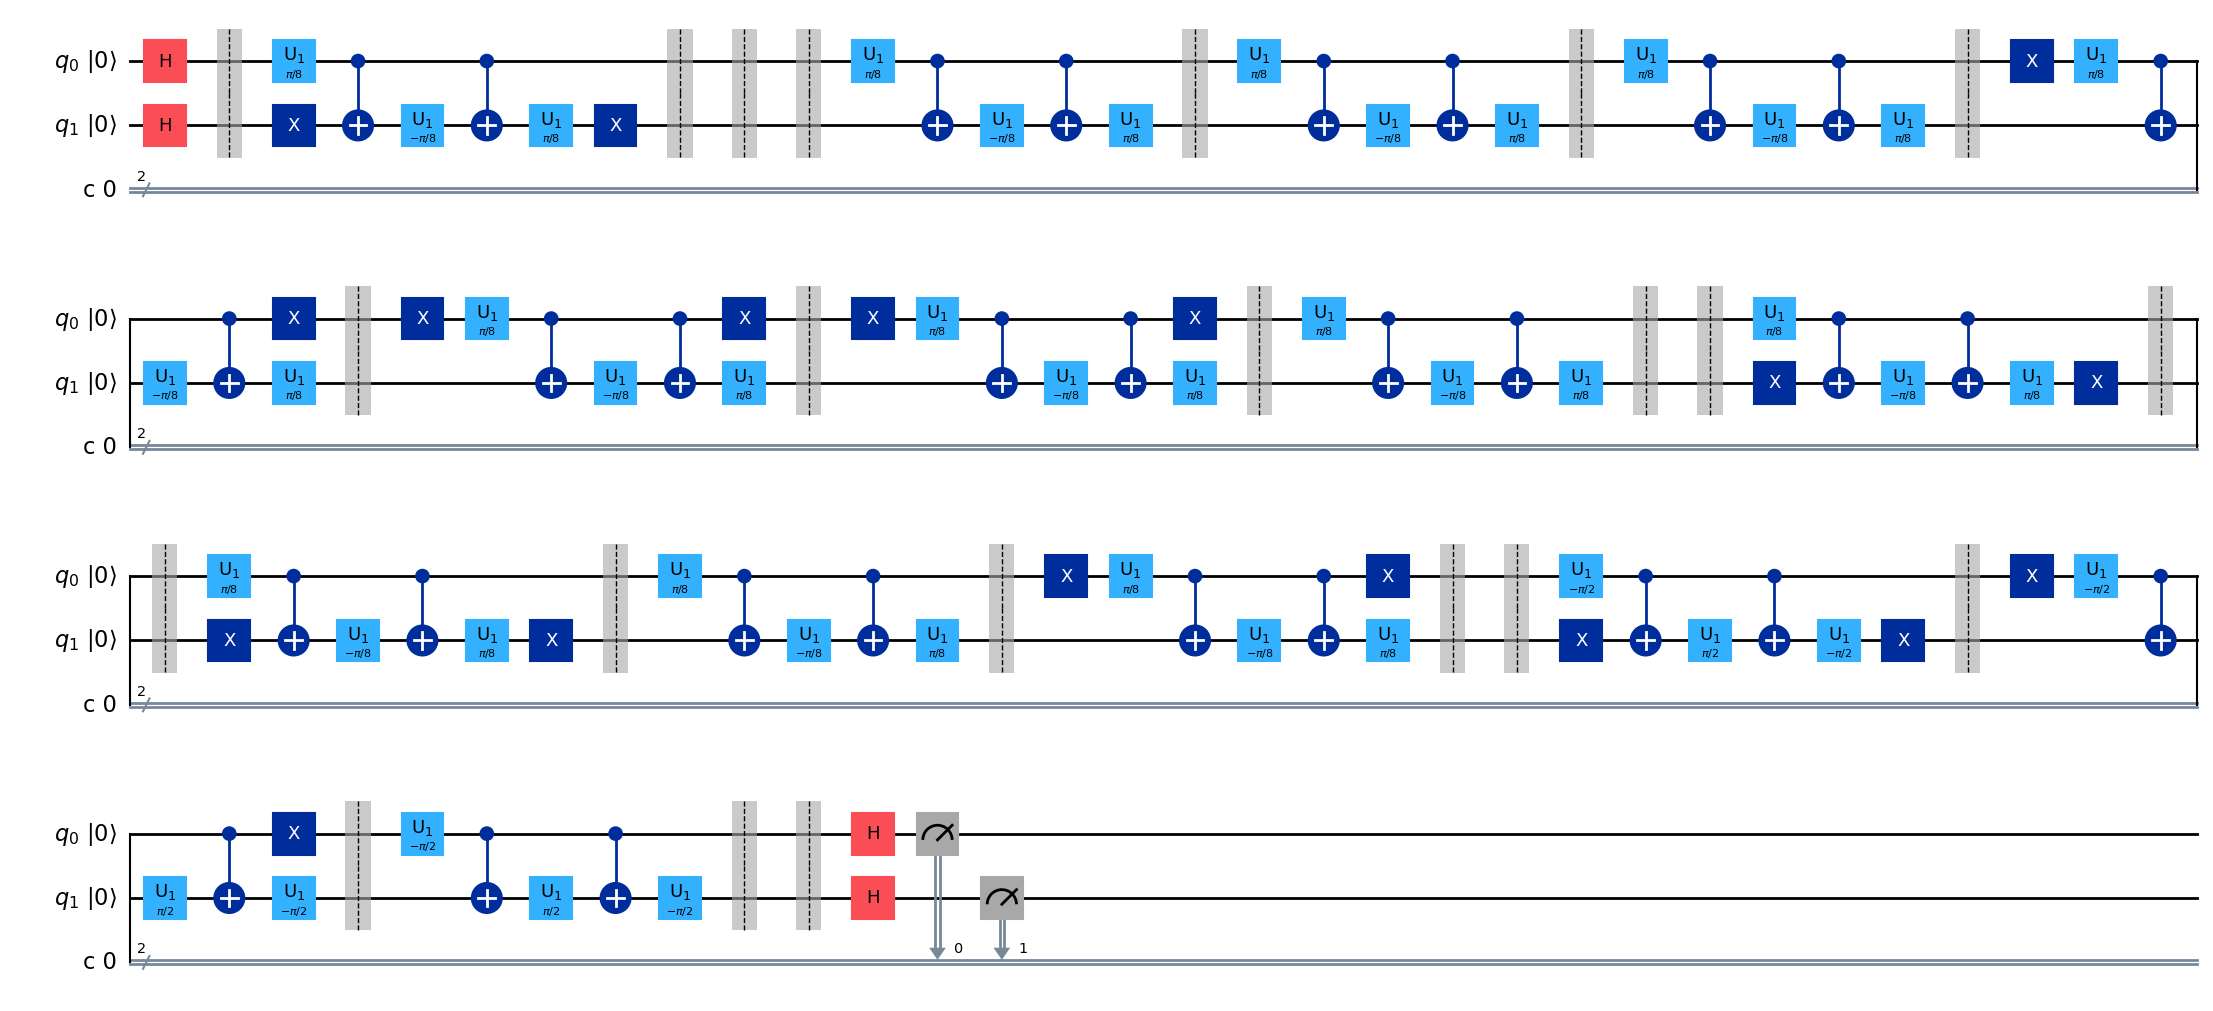

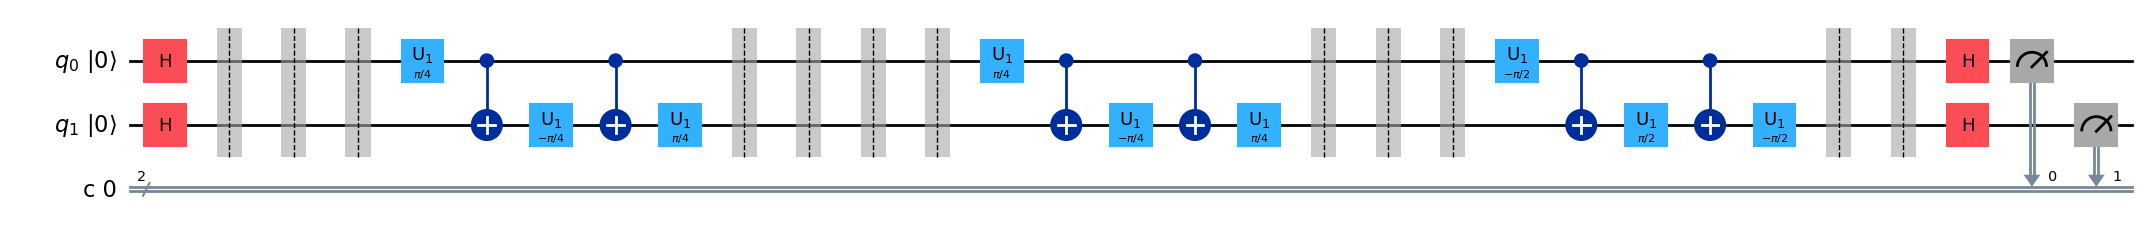

Saved: ../assets/figures/imdb-d4-flat-qos-results.png
Saved: ../assets/circuits/imdb-flat-qos-fixed-probe-full.png
Saved: ../assets/circuits/imdb-flat-qos-synthetic-entangled-control.png


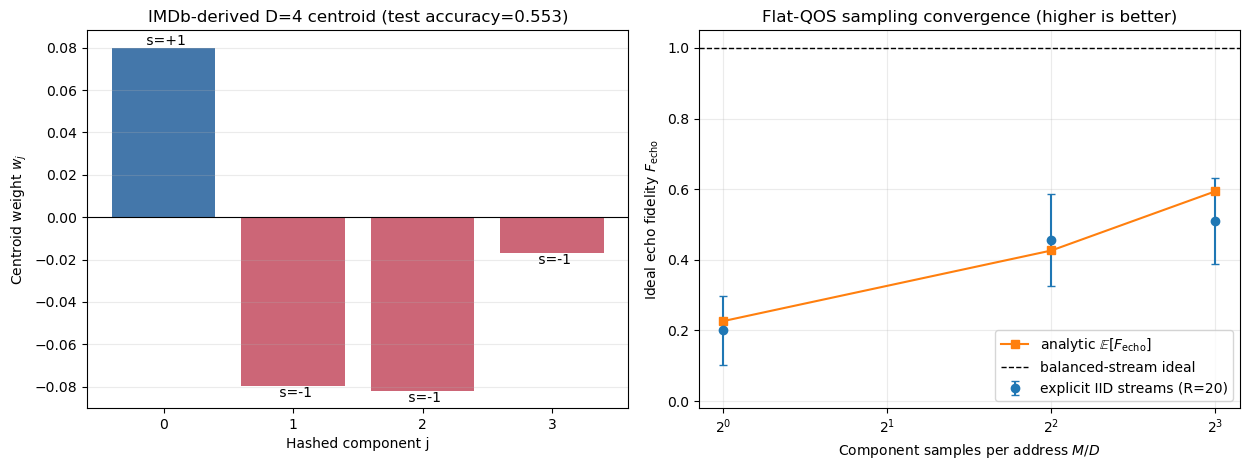

In [6]:
config_payload = {
    "seed": SEED,
    "iid_campaign_seed": SEED + 900,
    "synthetic_control_seed": SEED + 901,
    "D": D,
    "n_address": N_ADDRESS,
    "M_values": list(M_VALUES),
    "R_streams": R_STREAMS,
    "S_shots": S_SHOTS,
    "imdb_flat_sign_vector": sign_vector.tolist(),
    "imdb_num_negative_components_K": int(
        np.sum(sign_vector == -1)
    ),
    "hash_seed_tuned_for_sign_pattern": False,
    "synthetic_entangled_control_signs": (
        SYNTHETIC_ENTANGLED_SIGNS.tolist()
    ),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "qiskit": qiskit.__version__,
    "quafusqc_distribution": QUAFUSQC_VERSION,
    "noise_model": None,
    "hardware_submitted": False,
}
(RESULT_ROOT / "run_config.json").write_text(
    json.dumps(config_payload, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))

bar_colors = [
    "#4477AA" if sign > 0 else "#CC6677"
    for sign in sign_vector
]
axes[0].bar(
    weight_table["component_j"],
    weight_table["centroid_weight_wj"],
    color=bar_colors,
)
axes[0].axhline(0, color="black", linewidth=0.8)
for row in weight_table.itertuples(index=False):
    axes[0].text(
        row.component_j,
        row.centroid_weight_wj,
        f" s={row.flat_sign_sj:+d}",
        ha="center",
        va=(
            "bottom"
            if row.centroid_weight_wj >= 0
            else "top"
        ),
    )
axes[0].set(
    xlabel="Hashed component j",
    ylabel=r"Centroid weight $w_j$",
    title=(
        "IMDb-derived D=4 centroid "
        f"(test accuracy={centroid_test_accuracy:.3f})"
    ),
    xticks=np.arange(D),
)
axes[0].grid(axis="y", alpha=0.25)

axes[1].errorbar(
    ideal_summary["M_over_D"],
    ideal_summary["mean_MC_F_echo"],
    yerr=ideal_summary["approx_normal_ci95_halfwidth"],
    marker="o",
    capsize=3,
    linestyle="none",
    label=f"explicit IID streams (R={R_STREAMS})",
)
axes[1].plot(
    ideal_summary["M_over_D"],
    ideal_summary["analytic_E_F_echo"],
    marker="s",
    label=r"analytic $\mathbb{E}[F_{\rm echo}]$",
)
axes[1].axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1,
    label="balanced-stream ideal",
)
axes[1].set_xscale("log", base=2)
axes[1].set(
    xlabel=r"Component samples per address $M/D$",
    ylabel=r"Ideal echo fidelity $F_{\rm echo}$",
    title="Flat-QOS sampling convergence (higher is better)",
    ylim=(-0.02, 1.05),
)
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="best")

fig.tight_layout()
results_figure_path = (
    FIGURE_DIR / "imdb-d4-flat-qos-results.png"
)
fig.savefig(
    results_figure_path, dpi=180, bbox_inches="tight"
)
display(fig)

probe_circuit = qasm2.loads(representative_probe_qasm)
probe_figure = probe_circuit.draw(
    output="mpl",
    fold=32,
    idle_wires=False,
    initial_state=True,
)
probe_figure_path = (
    CIRCUIT_DIR / "imdb-flat-qos-fixed-probe-full.png"
)
probe_figure.savefig(
    probe_figure_path, dpi=180, bbox_inches="tight"
)
display(probe_figure)

synthetic_control_circuit = qasm2.loads(
    synthetic_entangled_qasm
)
synthetic_control_figure = synthetic_control_circuit.draw(
    output="mpl",
    fold=32,
    idle_wires=False,
    initial_state=True,
)
synthetic_control_figure_path = (
    CIRCUIT_DIR
    / "imdb-flat-qos-synthetic-entangled-control.png"
)
synthetic_control_figure.savefig(
    synthetic_control_figure_path,
    dpi=180,
    bbox_inches="tight",
)
display(synthetic_control_figure)

print("Saved:", results_figure_path)
print("Saved:", probe_figure_path)
print("Saved:", synthetic_control_figure_path)

## 5. 如何解释这些结果

1. 左图的 $w$ 和测试准确率来自真实 IMDb 文本，但维数被强制压到
   $D=4$，所以它只是可执行 pilot，不是高质量文本分类器。
2. $s=\operatorname{sign}(w)$ 只保留方向的符号，不保留权重大小；
   flat-QOS fidelity 不能当作 IMDb classification accuracy。
3. 右图的点是**无噪声、离线 statevector** 结果；误差棒是跨独立
   component streams 的均值近似区间，不是 finite-shot 区间。
4. balanced stream 的理想 fidelity 为 1，只说明采样计数完全平衡；
   真机上仍会受门误差、路由、读出和漂移影响。
5. 每条 QASM 已经预存完整 component stream，所以它验证的是静态
   gate-level functional emulation，不是在线 streaming-memory advantage。
6. 本次固定预处理自然得到的 IMDb sign pattern 为
   $(+1,-1,-1,-1)$，即 $K=3$；我们没有调 hash 来制造这个结果。
   另设的 $(+1,+1,+1,-1)$ 是独立的、非 IMDb 的已知纠缠校准目标，
   只用于检查电路功能，不能混入数据结论。

## 6. 下一层 general-vector $D=4$：设计说明，不冒充实现

flat $\pm1$ state 只有相位，没有非均匀振幅。要把真实
$w/\|w\|_2$ 制备成 general-vector state，原始
`qos_sampling.q_state_sketch` 还需要：

1. 固定并保存随机 sign map $h(j)$；
2. 把每个样本变成 Pauli-string phase
   $\exp(i\alpha_j Z^{j})$；
3. 使用一个 signal ancilla，把 $U$ 与 $U^\dagger$ 做 LCU，
   得到 $\sin(B)$ block encoding；
4. 用 degree-$d$ 的 arcsin QSVT 将 $\sin(B)$ 变回近似线性振幅；
5. 使用第二个 ancilla 提取 QSVT block 的实部；
6. 最后施加 $O_hH^{\otimes2}$，并对两个 ancillas 做 heralding。

因此 $D=4$ 的完整 logical register 至少是：

$$
\underbrace{2}_{\text{address}}
+
\underbrace{1}_{\sin(B)\text{ / QSVT signal}}
+
\underbrace{1}_{\operatorname{Re}\text{ LCU}}
=4\text{ qubits}.
$$

每个 sample 的受控 Pauli rotation 可写成

$$
\exp\left(i\alpha_j Z_a Z^{j}\right),
$$

用 CNOT parity ladder、$R_Z(-2\alpha_j)$ 和反计算实现。

真机必须同时报告两个量：

$$
p_{\rm succ}=P(a_1a_2=00),
$$

以及在小规模精确 target-state inverse $U_w^\dagger$ 之后

$$
F_{\rm cond}
=
\frac{
P(a_1a_2=00,\ \text{address}=00)
}{
P(a_1a_2=00)
}.
$$

不能只画条件 fidelity 而隐藏低 heralding probability。

### 实现前必须解决的归一化审计

原仓库显式采样函数先执行 `sampled_values /= norm`，随后又使用
`t = dim / norm / 3`；expected-operator 版本的归一化路径不同。
其内置测试使用单位范数向量。所以下一层应先把输入显式归一化并传
`norm=1`，再逐门与 JAX array 结果核对；在此之前，本 notebook
不声称已经实现 general-vector QOS。

## 7. Quafu-SQC 单任务提交模板：默认关闭

当前安装的发行包名是 `quafusqc`；该发行包保留的 Python import path
是 `quafu`。下面的 `from quafu import Task` 因此对应当前
Quafu-SQC SDK，不是在要求安装已弃用的 `pyquafu`。

提交前必须：

- 凭据只通过环境变量或隐藏输入提供；
- 先选择 manifest 中一条 functional control；
- 一次只提交一个 experiment id；
- 保存 Quafu 返回的 raw counts 和 transpiled QASM；
- 分别报告逻辑 CX 与编译后真实二比特门数。

本单元默认不会联网、不会读取 token、不会提交任务。

In [7]:
BACKEND = "Baihua"
COMPILER = "quarkcircuit"
SUBMIT_TO_HARDWARE = False
SELECTED_EXPERIMENT_ID = None


def backend_value_is_available(value):
    queue_value = (
        isinstance(value, (int, np.integer))
        and not isinstance(value, (bool, np.bool_))
        and int(value) >= 0
    )
    online_label = (
        isinstance(value, str)
        and value.strip().lower()
        in {"online", "available", "idle"}
    )
    return queue_value or online_label


assert backend_value_is_available(0)
assert backend_value_is_available(57)
assert backend_value_is_available("online")
assert not backend_value_is_available(True)
assert not backend_value_is_available(-1)
assert not backend_value_is_available("Maintenance")

selected_entry = None
if SELECTED_EXPERIMENT_ID is not None:
    selected_entry = next(
        (
            entry
            for entry in manifest_entries
            if entry["experiment_id"]
            == SELECTED_EXPERIMENT_ID
        ),
        None,
    )
    if selected_entry is None:
        raise ValueError(
            "Selected experiment id is not in the manifest."
        )

if SUBMIT_TO_HARDWARE:
    if selected_entry is None:
        raise ValueError(
            "Set SELECTED_EXPERIMENT_ID before enabling submission."
        )
    if not selected_entry["recommended_functional_pilot"]:
        raise ValueError(
            "First submission must be a functional-control pilot."
        )

    from quafu import Task  # provided by the quafusqc distribution

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入 Quafu-SQC token（输入不会显示）: "
    )
    task_manager = Task(token)
    live_status = task_manager.status()
    print("Live backend status:", live_status)
    if not isinstance(live_status, dict):
        raise RuntimeError(
            "Fail-closed: backend status response is not a mapping."
        )
    backend_value = live_status.get(BACKEND)
    if not backend_value_is_available(backend_value):
        raise RuntimeError(
            f"Fail-closed: unexpected {BACKEND} state "
            f"{backend_value!r}."
        )

    selected_qasm_path = (
        Path("..") / selected_entry["qasm_path"]
    )
    selected_qasm = selected_qasm_path.read_text(encoding="utf-8")
    observed_qasm_sha256 = hashlib.sha256(
        selected_qasm.encode("utf-8")
    ).hexdigest()
    if observed_qasm_sha256 != selected_entry["qasm_sha256"]:
        raise RuntimeError(
            "QASM hash no longer matches the selected manifest entry."
        )
    parsed_selected = qasm2.loads(selected_qasm)
    selected_measurements = int(
        parsed_selected.count_ops().get("measure", 0)
    )
    if (
        parsed_selected.num_qubits != 2
        or parsed_selected.num_clbits != 2
        or selected_measurements != 2
    ):
        raise RuntimeError(
            "Selected QASM is not the audited 2q/2c/2-measure schema."
        )

    task = {
        "chip": BACKEND,
        "name": selected_entry["experiment_id"],
        "circuit": selected_qasm,
        "shots": selected_entry["S_shots"],
        "compile": True,
        "options": {
            "compiler": COMPILER,
            "correct": False,
            "open_dd": None,
            "target_qubits": [],
        },
    }
    submitted_task_id = task_manager.run(task)
    valid_task_id = (
        isinstance(submitted_task_id, (int, np.integer))
        and not isinstance(
            submitted_task_id, (bool, np.bool_)
        )
        and int(submitted_task_id) > 0
    )
    if not valid_task_id:
        raise RuntimeError(
            "Submission did not return a positive integer task id; "
            f"received {submitted_task_id!r}."
        )
    submitted_task_id = int(submitted_task_id)
    receipt = {
        "experiment_id": selected_entry["experiment_id"],
        "task_id": submitted_task_id,
        "submitted_at_utc":
            pd.Timestamp.now(tz="UTC").isoformat(),
        "backend": BACKEND,
        "compiler": COMPILER,
        "shots": selected_entry["S_shots"],
        "qasm_path": selected_entry["qasm_path"],
        "qasm_sha256": observed_qasm_sha256,
    }
    RAW_RESULT_DIR.mkdir(parents=True, exist_ok=True)
    receipt_path = (
        RAW_RESULT_DIR
        / f"submission_receipt_{submitted_task_id}.json"
    )
    receipt_path.write_text(
        json.dumps(receipt, indent=2), encoding="utf-8"
    )
    print("Submitted one task:", submitted_task_id)
    print("Saved receipt:", receipt_path)
else:
    print("Hardware submission disabled.")

Hardware submission disabled.


### 取回并解析 flat-QOS 真机结果

提交完成后，把 `{experiment_id: task_id}` 填入 `RESULT_TASK_IDS`。
解析器会保存完整 raw JSON、returned transpiled QASM 及其 hash，并计算
全零 echo probability。所有开关仍默认关闭。

In [8]:
RESULT_TASK_IDS = {}
FETCH_REAL_RESULTS = False
RAW_RESULT_DIR.mkdir(parents=True, exist_ok=True)


def flat_counts_metrics(counts, expected_shots):
    empty = {
        "shots_observed": 0,
        "shots_match_manifest": False,
        "shot_F_echo": np.nan,
    }
    if not isinstance(counts, dict) or not counts:
        return {**empty, "measurement_parse_reason": "missing_counts"}
    cleaned = {}
    for raw_bits, raw_count in counts.items():
        bits = str(raw_bits).replace(" ", "")
        if len(bits) != 2 or set(bits) - {"0", "1"}:
            return {
                **empty,
                "measurement_parse_reason":
                    f"invalid_bitstring:{raw_bits}",
            }
        if isinstance(raw_count, (bool, np.bool_)):
            return {
                **empty,
                "measurement_parse_reason":
                    f"invalid_count:{raw_bits}:{raw_count!r}",
            }
        if (
            isinstance(raw_count, (float, np.floating))
            and not float(raw_count).is_integer()
        ):
            return {
                **empty,
                "measurement_parse_reason":
                    f"invalid_count:{raw_bits}:{raw_count!r}",
            }
        try:
            count = int(raw_count)
        except (TypeError, ValueError, OverflowError):
            return {
                **empty,
                "measurement_parse_reason":
                    f"invalid_count:{raw_bits}:{raw_count!r}",
            }
        if count < 0:
            return {
                **empty,
                "measurement_parse_reason":
                    f"negative_count:{raw_bits}:{count}",
            }
        cleaned[bits] = cleaned.get(bits, 0) + count
    total = sum(cleaned.values())
    if total <= 0:
        return {
            **empty,
            "measurement_parse_reason": "zero_total_counts",
        }
    return {
        "shots_observed": total,
        "shots_match_manifest": total == int(expected_shots),
        "shot_F_echo": cleaned.get("00", 0) / total,
        "measurement_parse_reason": "ok",
    }


def returned_flat_qasm_metrics(qasm_text):
    empty = {
        "returned_depth": np.nan,
        "returned_two_qubit_gates": np.nan,
        "returned_two_qubit_depth": np.nan,
        "returned_three_plus_qubit_gates": np.nan,
        "returned_barriers": np.nan,
        "returned_ops": {},
    }
    if not qasm_text:
        return {
            **empty,
            "returned_qasm_parse_reason":
                "missing_transpiled_qasm",
        }
    try:
        circuit = qasm2.loads(qasm_text)
    except Exception as exc:
        return {
            **empty,
            "returned_qasm_parse_reason":
                f"parse_error:{type(exc).__name__}:{exc}",
        }
    gate_items = [
        item for item in circuit.data
        if isinstance(item.operation, Gate)
    ]
    return {
        "returned_depth": circuit.depth(),
        "returned_two_qubit_gates": sum(
            int(item.operation.num_qubits == 2)
            for item in gate_items
        ),
        "returned_two_qubit_depth": circuit.depth(
            filter_function=lambda item: (
                isinstance(item.operation, Gate)
                and item.operation.num_qubits == 2
            )
        ),
        "returned_three_plus_qubit_gates": sum(
            int(item.operation.num_qubits >= 3)
            for item in gate_items
        ),
        "returned_barriers": sum(
            int(item.operation.name == "barrier")
            for item in circuit.data
        ),
        "returned_ops": {
            str(k): int(v)
            for k, v in circuit.count_ops().items()
        },
        "returned_qasm_parse_reason": "ok",
    }


_flat_parser_smoke_cases = [
    (None, "missing_counts"),
    ({}, "missing_counts"),
    ({"00": 0}, "zero_total_counts"),
    ({"bad": 1}, "invalid_bitstring:bad"),
    ({"00": 1.5}, "invalid_count:00:1.5"),
    ({"00": -1}, "negative_count:00:-1"),
    ({"00": 2, "11": 2}, "ok"),
]
for _counts, _reason in _flat_parser_smoke_cases:
    assert (
        flat_counts_metrics(_counts, 4)[
            "measurement_parse_reason"
        ]
        == _reason
    )


if FETCH_REAL_RESULTS:
    from quafu import Task

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入 Quafu-SQC token（输入不会显示）: "
    )
    task_manager = Task(token)
    parsed_rows = []
    for experiment_id, task_id in RESULT_TASK_IDS.items():
        entry = next(
            (
                item for item in manifest_entries
                if item["experiment_id"] == experiment_id
            ),
            None,
        )
        if entry is None:
            raise ValueError(
                f"Unknown experiment id: {experiment_id!r}."
            )
        valid_task_id = (
            isinstance(task_id, (int, np.integer))
            and not isinstance(task_id, (bool, np.bool_))
            and int(task_id) > 0
        )
        if not valid_task_id:
            raise ValueError(
                "Every result task id must be a positive integer; "
                f"received {task_id!r} for {experiment_id!r}."
            )
        task_id = int(task_id)
        result = task_manager.result(task_id, timeout=60)
        if not isinstance(result, dict):
            result = {
                "status": "invalid_result_type",
                "finished": False,
                "error":
                    f"Expected mapping, got {type(result).__name__}: "
                    f"{result!r}",
            }
        raw_path = (
            RAW_RESULT_DIR / f"{experiment_id}_{task_id}.json"
        )
        raw_path.write_text(
            json.dumps(result, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
        result_status = str(result.get("status", "")).lower()
        if result_status in {"finished", "completed", "success"}:
            measurement = flat_counts_metrics(
                result.get("count") or {},
                entry["S_shots"],
            )
        else:
            measurement = flat_counts_metrics(
                {}, entry["S_shots"]
            )
            measurement["measurement_parse_reason"] = (
                f"nonfinished_status:{result.get('status')!r}"
            )
        returned_qasm = result.get("transpiled", "")
        returned_qasm_path = None
        returned_qasm_sha256 = None
        if returned_qasm:
            returned_qasm_path = (
                RAW_RESULT_DIR
                / f"{experiment_id}_{task_id}_transpiled.qasm"
            )
            returned_qasm_path.write_text(
                returned_qasm, encoding="utf-8"
            )
            returned_qasm_sha256 = hashlib.sha256(
                returned_qasm.encode("utf-8")
            ).hexdigest()
        parsed_rows.append({
            "experiment_id": experiment_id,
            "task_id": task_id,
            "status": result.get("status"),
            "finished": result.get("finished"),
            "error": result.get("error", ""),
            "ideal_F_echo": entry["ideal_F_echo"],
            "returned_qasm_path":
                str(returned_qasm_path)
                if returned_qasm_path else None,
            "returned_qasm_sha256": returned_qasm_sha256,
            **measurement,
            **returned_flat_qasm_metrics(returned_qasm),
        })
    parsed_real_results = pd.DataFrame(parsed_rows)
    parsed_real_results.to_csv(
        RESULT_ROOT / "parsed_real_results.csv",
        index=False,
    )
    display(parsed_real_results)
else:
    print("Real-result retrieval disabled.")

Real-result retrieval disabled.


## 8. 本章完成条件与边界

已完成：

- IMDb 官方 split 的 $D=4$ signed-hash class-centroid；
- IMDb-derived $s=\operatorname{sign}(w)$；
- 两地址 qubits、零工作 ancilla 的 CP-based flat-QOS；
- H-only、exact-pair、balanced、phase-count controls，以及独立的
  synthetic $(+1,+1,+1,-1)$ entangled calibration control；
- $M=4,16,32$，每点 $R=20$ 条 IID stream；
- direct formula、完整 statevector 与 QASM 的等价检查；
- QASM、hash、manifest、图和默认关闭的 Quafu-SQC 模板。

没有完成：

- 真实 Quafu-SQC counts；
- 在线 coherent streaming controller；
- general-vector 两层 LCU / QSVT；
- amplitude amplification；
- end-to-end IMDb QOS training、LS-SVM 或指数优势实验。

因此，最准确的项目结论是：

> 我们已经把一个**真实 IMDb 派生的 flat sign vector**映射成可审计、
> 可提交但尚未提交的 QOS gate-level pilot；更深的 general-vector
> 和 LS-SVM 仍是后续研究任务。

In [9]:
expected_files = [
    RESULT_ROOT / "imdb_d4_model_summary.json",
    RESULT_ROOT / "imdb_d4_target.json",
    RESULT_ROOT / "imdb_d4_weights.csv",
    RESULT_ROOT / "manifest.json",
    RESULT_ROOT / "manifest.csv",
    RESULT_ROOT / "ideal_iid_streams.csv",
    RESULT_ROOT / "ideal_summary.csv",
    RESULT_ROOT / "run_config.json",
    FIGURE_DIR / "imdb-d4-flat-qos-results.png",
    CIRCUIT_DIR / "imdb-flat-qos-cp-update.png",
    CIRCUIT_DIR / "imdb-flat-qos-echo-overview.png",
    CIRCUIT_DIR / "imdb-flat-qos-fixed-probe-full.png",
    CIRCUIT_DIR
    / "imdb-flat-qos-synthetic-entangled-control.png",
]

missing = [str(path) for path in expected_files if not path.exists()]
if missing:
    raise AssertionError(f"Missing expected artifacts: {missing}")

print("Artifact checks passed:", len(expected_files))
print("QASM count:", len(list(QASM_DIR.glob("*.qasm"))))
print("No Quafu-SQC hardware task was submitted.")

Artifact checks passed: 13
QASM count: 65
No Quafu-SQC hardware task was submitted.
